In [2]:
import pandas as pd

# 方法1（推荐）：加 r 防止转义问题
file_path = r"C:\Users\86180\Desktop\毕业材料\毕业论文\论文数据\情感结果.xlsx"

df = pd.read_excel(file_path)

# 查看前几行
print(df.head())

                               name          address          city state  \
0           Reading Terminal Market     51 N 12th St  Philadelphia    PA   
1                    Dim Sum Garden     1020 Race St  Philadelphia    PA   
2  Nan Zhou Hand Drawn Noodle House     1022 Race St  Philadelphia    PA   
3                            Sampan    124 S 13th St  Philadelphia    PA   
4                          Buddakan  325 Chestnut St  Philadelphia    PA   

   stars  review_count  is_open  price_level  expectation_gap   stars.1  
0    4.5          5721        1            2         0.092687  4.513889  
1    4.0          2672        1            2         0.228670  3.877370  
2    4.0          2188        1            2         0.281368  4.083815  
3    4.0          2000        1            2         0.281368  4.083815  
4    4.0          1561        1            3         0.282704  3.836131  


In [3]:
# 去除缺失值（很重要）
df = df.dropna(subset=[
    'price_level', 'review_count', 'stars'
])

In [4]:
import statsmodels.api as sm

# 价格 → 期望偏差
X = sm.add_constant(df['price_level'])
M = df['expectation_gap']

model_a = sm.OLS(M, X).fit()
print(model_a.summary())

                            OLS Regression Results                            
Dep. Variable:        expectation_gap   R-squared:                       0.094
Model:                            OLS   Adj. R-squared:                  0.084
Method:                 Least Squares   F-statistic:                     10.13
Date:                Fri, 03 Apr 2026   Prob (F-statistic):            0.00196
Time:                        16:36:30   Log-Likelihood:                 78.365
No. Observations:                 100   AIC:                            -152.7
Df Residuals:                      98   BIC:                            -147.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1997      0.036      5.619      

In [5]:
X = df[['price_level', 'expectation_gap']]
X = sm.add_constant(X)
Y = df['stars']

model_b = sm.OLS(Y, X).fit()
print(model_b.summary())

                            OLS Regression Results                            
Dep. Variable:                  stars   R-squared:                       0.590
Model:                            OLS   Adj. R-squared:                  0.582
Method:                 Least Squares   F-statistic:                     69.92
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           1.57e-19
Time:                        16:36:30   Log-Likelihood:                -19.766
No. Observations:                 100   AIC:                             45.53
Df Residuals:                      97   BIC:                             53.35
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.4954      0.110     

In [6]:
import numpy as np

# a路径
X = sm.add_constant(df['review_count'])
model_a2 = sm.OLS(df['expectation_gap'], X).fit()
print(model_a2.summary())



                            OLS Regression Results                            
Dep. Variable:        expectation_gap   R-squared:                       0.048
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     4.942
Date:                Fri, 03 Apr 2026   Prob (F-statistic):             0.0285
Time:                        16:36:30   Log-Likelihood:                 75.909
No. Observations:                 100   AIC:                            -147.8
Df Residuals:                      98   BIC:                            -142.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.3231      0.014     23.874   

In [7]:
# b路径
X = df[['review_count', 'expectation_gap']]
X = sm.add_constant(X)
model_b2 = sm.OLS(df['stars'], X).fit()

print(model_b2.summary())

                            OLS Regression Results                            
Dep. Variable:                  stars   R-squared:                       0.566
Model:                            OLS   Adj. R-squared:                  0.557
Method:                 Least Squares   F-statistic:                     63.29
Date:                Fri, 03 Apr 2026   Prob (F-statistic):           2.58e-18
Time:                        16:36:30   Log-Likelihood:                -22.648
No. Observations:                 100   AIC:                             51.30
Df Residuals:                      97   BIC:                             59.11
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               4.6384      0.095     

In [8]:
from math import sqrt
from scipy.stats import norm

a = model_a.params[1]
b = model_b.params['expectation_gap']

sa = model_a.bse[1]
sb = model_b.bse['expectation_gap']

z = (a * b) / sqrt(b**2 * sa**2 + a**2 * sb**2)
p_value = 2 * (1 - norm.cdf(abs(z)))

print("Sobel Z:", z)
print("p-value:", p_value)

Sobel Z: -3.0719742289774197
p-value: 0.002126480833926303


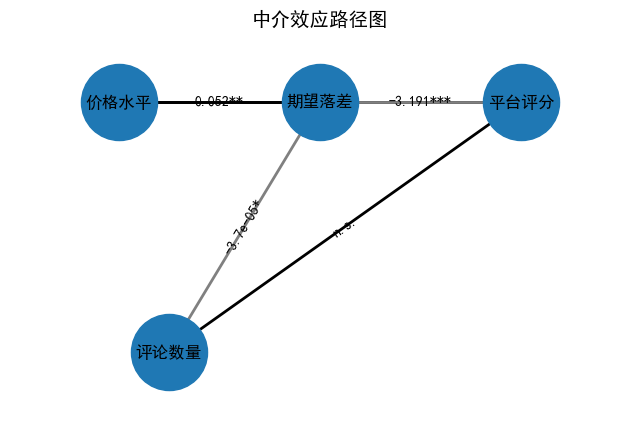

In [9]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()

# 节点
G.add_nodes_from(["价格水平", "评论数量", "期望落差", "平台评分"])

# 边
G.add_edge("价格水平", "期望落差", weight=0.0516)
G.add_edge("期望落差", "平台评分", weight=-3.191)
G.add_edge("价格水平", "平台评分", weight=0.1200)
G.add_edge("评论数量", "期望落差", weight=-0.000037)
G.add_edge("评论数量", "平台评分", weight=0.000047)

# 布局
pos = {
    "价格水平": (0.1, 0.5),
    "评论数量": (0.2, 0.4),
    "期望落差": (0.5, 0.5),
    "平台评分": (0.9, 0.5)
}

# 颜色（正负）
edge_colors = []
for u, v, d in G.edges(data=True):
    if d['weight'] > 0:
        edge_colors.append('black')
    else:
        edge_colors.append('gray')

# 画布
plt.figure(figsize=(8, 5))
plt.margins(0.2)

# 节点
nx.draw_networkx_nodes(G, pos, node_size=3000)
nx.draw_networkx_labels(G, pos, font_size=12)

# ⭐ 线（无箭头）
nx.draw_networkx_edges(
    G, pos,
    edge_color=edge_colors,
    width=2,
    arrows=False   # ⭐ 关键：去掉箭头
)

# ⭐ 系数
edge_labels = {
    ("价格水平", "期望落差"): "0.052**",
    ("期望落差", "平台评分"): "-3.191***",
    ("价格水平", "平台评分"): "0.120*",
    ("评论数量", "期望落差"): "-3.7e-05*",
    ("评论数量", "平台评分"): "n.s."
}

# ⭐ 放在中间
nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels=edge_labels,
    font_size=10,
    label_pos=0.5,   # ⭐ 核心：居中
    bbox=dict(alpha=0)  # 去掉白框
)

# 中文
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.title("中介效应路径图", fontsize=14)

plt.axis('off')
plt.show()

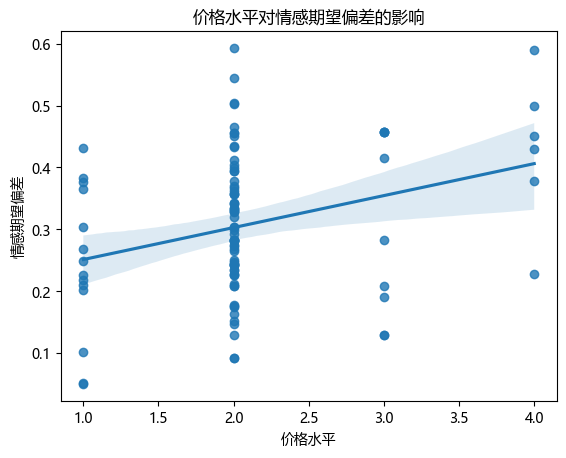

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Windows 正确中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# ✅ 必须用你数据里的英文列名！！！
sns.regplot(data=df, x="price_level", y="expectation_gap")

# 标题你想用中文就用中文
plt.title("价格水平对情感期望偏差的影响")
plt.xlabel("价格水平")
plt.ylabel("情感期望偏差")
plt.show()

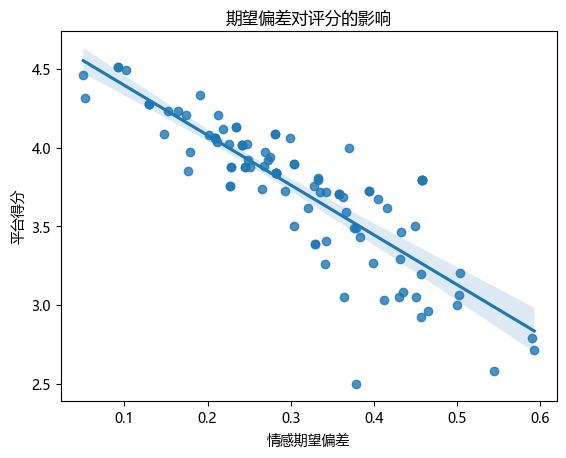

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

# 解决中文乱码（Windows）
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 正确画图（你这里的变量名是对的）
sns.regplot(data=df, x="expectation_gap", y="stars.1")

plt.title("期望偏差对评分的影响")
plt.xlabel("情感期望偏差")
plt.ylabel("平台得分")
plt.show()

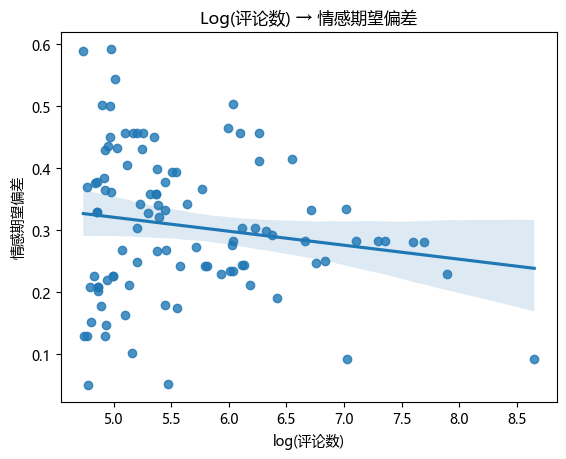

In [21]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.regplot(
    data=df,
    x=np.log1p(df["review_count"]),  # ⭐ log(1+x)，避免log(0)
    y="expectation_gap"
)

plt.xlabel("log(评论数)")
plt.ylabel("情感期望偏差")
plt.title("Log(评论数) → 情感期望偏差")

plt.show()

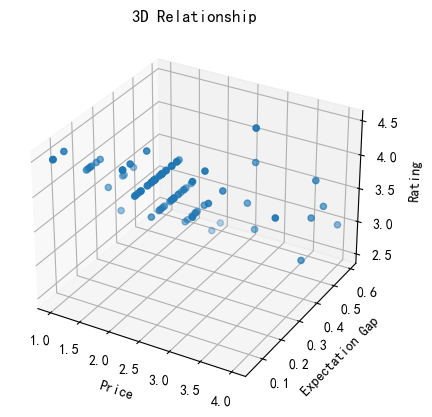

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(df['price_level'], 
           df['expectation_gap'], 
           df['stars'])

ax.set_xlabel('Price')
ax.set_ylabel('Expectation Gap')
ax.set_zlabel('Rating')

plt.title("3D Relationship")
plt.show()

In [ ]:
import pandas as pd

# 选取变量
cols = ["stars.1", "review_count", "price_level", "expectation_gap"]

desc = df[cols].describe().T

# 只保留论文需要的统计量
desc = desc[["count", "mean", "std", "min", "max"]]

# 重命名（中文论文用）
desc.columns = ["样本量", "均值", "标准差", "最小值", "最大值"]

# 保留4位小数
desc = desc.round(4)

print(desc)

                   样本量        均值       标准差       最小值        最大值
stars.1          100.0    3.7400    0.4332    2.5000     4.5139
review_count     100.0  437.4900  695.5974  113.0000  5721.0000
price_level      100.0    2.0800    0.6917    1.0000     4.0000
expectation_gap  100.0    0.3071    0.1167    0.0505     0.5930


In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# 选择自变量（一定不要放因变量）
X = df[["price_level", "review_count", "expectation_gap"]]

# 加常数项
import statsmodels.api as sm
X = sm.add_constant(X)

# 计算VIF
vif_data = pd.DataFrame()
vif_data["变量"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif_data)

                变量        VIF
0            const  14.541159
1      price_level   1.109741
2     review_count   1.056544
3  expectation_gap   1.165693
